In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
#1. Load the Uber Ride Booking dataset into a Pandas DataFrame using Python
df = pd.read_csv(r"C:\Users\sales\OneDrive\Desktop\jupyter notebook\ncr_ride_bookings.csv")

In [10]:
#2. Find the number of rows and columns in the dataset
df.shape

(150000, 21)

In [24]:
#3. Display the first 5 and last 5 records of the dataset.
df.head()

SyntaxError: invalid syntax (1489238148.py, line 1)

In [25]:
#3. Display the first 5 and last 5 records of the dataset.
df.tail()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [26]:
#4. Display all column names and identify the data type of each column.
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [27]:
#4. Display all column names and identify the data type of each column.
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [37]:
#5. Separate the columns into numerical, categorical, and date/time variables.
print("Numerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nDate/Time Columns:")
print(df.select_dtypes(include="datetime").columns.tolist())

Numerical Columns:
['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']

Categorical Columns:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason', 'Payment Method']

Date/Time Columns:
[]


In [28]:
#6. Generate descriptive statistics for all numerical columns
df.describe()


,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [31]:
#7. Find the number and percentage of missing values in every column.
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing

,Missing Count,Missing Percentage
Date,0,0.0
Time,0,0.0
Booking ID,0,0.0
Booking Status,0,0.0
Customer ID,0,0.0
Vehicle Type,0,0.0
Pickup Location,0,0.0
Drop Location,0,0.0
Avg VTAT,10500,7.0
Avg CTAT,48000,32.0


In [41]:
#8. Identify the columns having the highest number and percentage of missing values.
df["Booking Status"].value_counts(dropna=False)

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [50]:
#9. Handle the missing values using an appropriate method and explain why the method was selected.
df_clean = df.copy()

# Replace missing reason fields with "Not Applicable"
reason_cols = [
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason"
]

df_clean[reason_cols] = df_clean[reason_cols].fillna("Not Applicable")

# Keep numerical values as NaN where the value is not applicable/unavailable
df_clean.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer         0
Cancelled Rides by Driver            123000
Driver Cancellation Reason                0
Incomplete Rides                     141000
Incomplete Rides Reason                   0
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [52]:
#10. Find and remove duplicate records, then verify that no unwanted duplicates remain.
# Find duplicate rows
print("Duplicate rows:", df_clean.duplicated().sum())

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Verify
print("Duplicates after removal:", df_clean.duplicated().sum())

Duplicate rows: 0
Duplicates after removal: 0


In [55]:
#11. Convert date and time columns into appropriate datetime formats
df = df_clean
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"])
df[["Date", "Time"]].dtypes

Date    datetime64[ns]
Time    datetime64[ns]
dtype: object

In [58]:
#12. Check the dataset for logically invalid values such as negative distances, negative booking values, impossible
#ages, and invalid ratings.
df.describe()
#Observation: No negative values were found in Avg VTAT, Avg CTAT, Booking Value, or Ride Distance. Driver Ratings and Customer Ratings range from 3 to 5. The dataset does not contain an age column, so impossible-age validation is not applicable.

,Date,Time,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,2024-06-30 16:42:40.320000,2026-09-09 14:32:00.931033344,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
min,2024-01-01 00:00:00,2026-09-09 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,2026-09-09 10:20:25,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,2024-07-01 00:00:00,2026-09-09 15:23:33,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,2024-09-30 00:00:00,2026-09-09 18:57:31,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,2024-12-30 00:00:00,2026-09-09 23:59:59,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000
std,NaN,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819


In [63]:
#13. Handle all invalid values appropriately and explain the treatment.

# No invalid values were found in the numerical variables,
# so no treatment was required.

In [64]:
#14. Find the number and percentage of bookings for each booking status.

status_summary = pd.DataFrame({
    "Booking Count": df["Booking Status"].value_counts(),
    "Percentage": df["Booking Status"].value_counts(normalize=True) * 100
})

status_summary

,Booking Count,Percentage
Booking Status,,
Completed,93000,62.0
Cancelled by Driver,27000,18.0
No Driver Found,10500,7.0
Cancelled by Customer,10500,7.0
Incomplete,9000,6.0


In [65]:
#15. Identify the most and least common booking status.

print("Most common status:", df["Booking Status"].mode()[0])
print("Least common status:", df["Booking Status"].value_counts().idxmin())

Most common status: Completed
Least common status: Incomplete


In [66]:
#16. Find the number of bookings for each vehicle type.

df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [67]:
#17. Identify the most and least popular vehicle types.

print("Most popular vehicle type:", df["Vehicle Type"].value_counts().idxmax())
print("Least popular vehicle type:", df["Vehicle Type"].value_counts().idxmin())

Most popular vehicle type: Auto
Least popular vehicle type: Uber XL


In [68]:
#18. Find the number and percentage of bookings for each payment method.

payment_summary = pd.DataFrame({
    "Booking Count": df["Payment Method"].value_counts(),
    "Percentage": df["Payment Method"].value_counts(normalize=True) * 100
})

payment_summary

,Booking Count,Percentage
Payment Method,,
UPI,45909,45.008824
Cash,25367,24.869608
Uber Wallet,12276,12.035294
Credit Card,10209,10.008824
Debit Card,8239,8.077451


In [69]:
#19. Identify the most frequently used payment method.

print("Most frequently used payment method:", df["Payment Method"].mode()[0])

Most frequently used payment method: UPI


In [70]:
#20. Calculate statistical measures of ride distance.

ride_distance = df["Ride Distance"].dropna()

print("Mean:", ride_distance.mean())
print("Median:", ride_distance.median())
print("Mode:", ride_distance.mode()[0])
print("Minimum:", ride_distance.min())
print("Maximum:", ride_distance.max())
print("Range:", ride_distance.max() - ride_distance.min())
print("Variance:", ride_distance.var())
print("Standard Deviation:", ride_distance.std())
print("Q1:", ride_distance.quantile(0.25))
print("Q3:", ride_distance.quantile(0.75))
print("IQR:", ride_distance.quantile(0.75) - ride_distance.quantile(0.25))

Mean: 24.63701166666667
Median: 23.72
Mode: 9.61
Minimum: 1.0
Maximum: 50.0
Range: 49.0
Variance: 196.05987745395635
Standard Deviation: 14.002138317198424
Q1: 12.46
Q3: 36.82
IQR: 24.36


In [71]:
#21. Calculate the mean, median, mode, minimum, maximum, range, variance,
#standard deviation, Q1, Q3, and IQR of booking value.

booking_value = df["Booking Value"].dropna()

print("Mean:", booking_value.mean())
print("Median:", booking_value.median())
print("Mode:", booking_value.mode()[0])
print("Minimum:", booking_value.min())
print("Maximum:", booking_value.max())
print("Range:", booking_value.max() - booking_value.min())
print("Variance:", booking_value.var())
print("Standard Deviation:", booking_value.std())
print("Q1:", booking_value.quantile(0.25))
print("Q3:", booking_value.quantile(0.75))
print("IQR:", booking_value.quantile(0.75) - booking_value.quantile(0.25))

Mean: 508.29591176470586
Median: 414.0
Mode: 176.0
Minimum: 50.0
Maximum: 4277.0
Range: 4227.0
Variance: 156662.21076182358
Standard Deviation: 395.80577403800413
Q1: 234.0
Q3: 689.0
IQR: 455.0


In [72]:
#22. Analyze the distribution of driver ratings using appropriate statistical measures.

df["Driver Ratings"].describe()

count    93000.000000
mean         4.230992
std          0.436871
min          3.000000
25%          4.100000
50%          4.300000
75%          4.600000
max          5.000000
Name: Driver Ratings, dtype: float64

In [73]:
#23. Analyze the distribution of customer ratings using appropriate statistical measures.

df["Customer Rating"].describe()

count    93000.000000
mean         4.404584
std          0.437819
min          3.000000
25%          4.200000
50%          4.500000
75%          4.800000
max          5.000000
Name: Customer Rating, dtype: float64

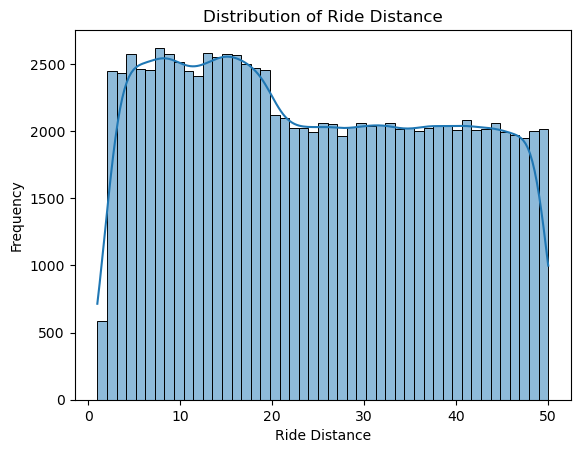

In [74]:
#24. Create a histogram and KDE plot for ride distance and interpret the distribution.

sns.histplot(df["Ride Distance"].dropna(), kde=True)
plt.title("Distribution of Ride Distance")
plt.xlabel("Ride Distance")
plt.ylabel("Frequency")
plt.show()

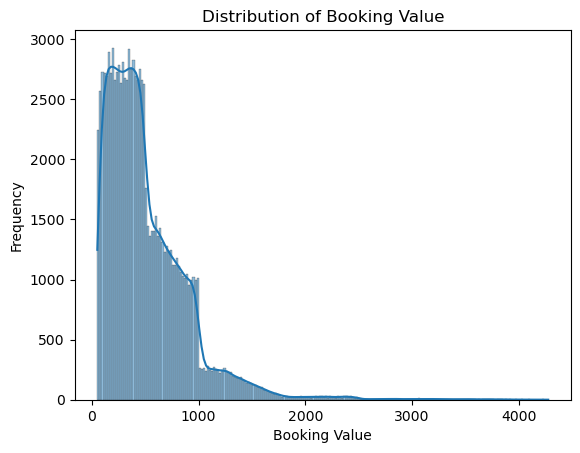

In [75]:
#25. Create a histogram and KDE plot for booking value and interpret the distribution.

sns.histplot(df["Booking Value"].dropna(), kde=True)
plt.title("Distribution of Booking Value")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")
plt.show()

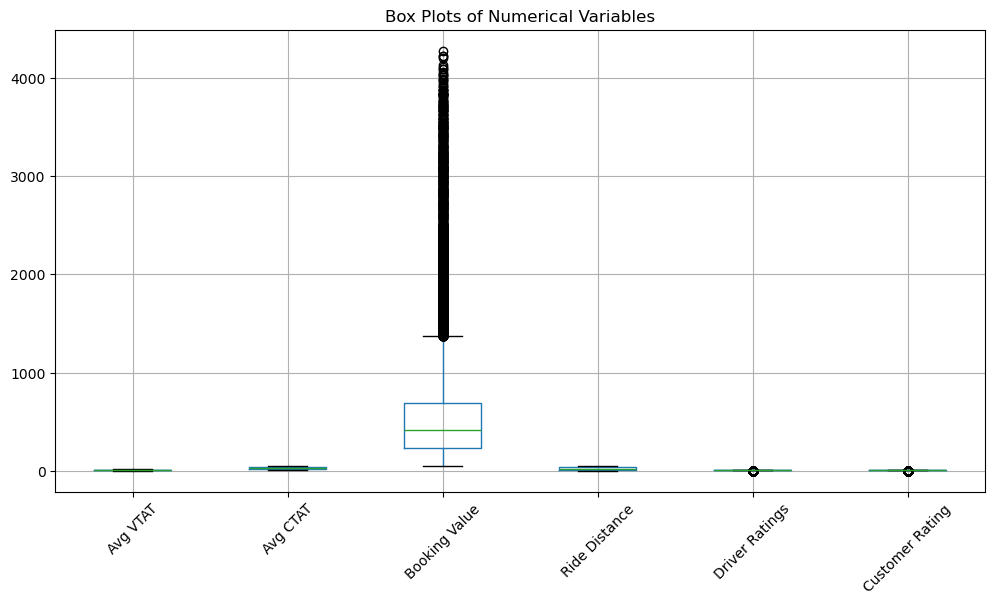

In [76]:
#26. Create box plots for ride distance, booking value, ride time, and other important numerical variables.

numerical_cols = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

df[numerical_cols].boxplot(figsize=(12, 6))
plt.title("Box Plots of Numerical Variables")
plt.xticks(rotation=45)
plt.show()

In [77]:
#27. Compare booking status across different vehicle types.

pd.crosstab(df["Vehicle Type"], df["Booking Status"])

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,2680,6643,23155,2260,2681
Bike,1575,4077,14034,1328,1503
Go Mini,2097,5330,18549,1815,2015
Go Sedan,1832,5031,16676,1642,1960
Premier Sedan,1266,3250,11252,1063,1280
Uber XL,327,762,2783,262,315
eBike,723,1907,6551,630,746


In [78]:
#28. Compare the average, median, and total booking value across vehicle types.

vehicle_booking = df.groupby("Vehicle Type")["Booking Value"].agg(
    Average="mean",
    Median="median",
    Total="sum"
)

vehicle_booking

,Average,Median,Total
Vehicle Type,,,
Auto,506.725241,414.0,12878422.0
Bike,510.200299,416.0,7837697.0
Go Mini,507.684934,412.0,10338496.0
Go Sedan,511.503385,416.0,9369719.0
Premier Sedan,509.568169,416.0,6275332.0
Uber XL,501.816749,406.0,1528032.0
eBike,503.897090,410.0,3618485.0


In [79]:
#29. Compare the average ride distance across vehicle types.

df.groupby("Vehicle Type")["Ride Distance"].mean().sort_values(ascending=False)

Vehicle Type
eBike            24.990415
Bike             24.649546
Auto             24.615996
Go Mini          24.612090
Go Sedan         24.609325
Premier Sedan    24.598956
Uber XL          24.402893
Name: Ride Distance, dtype: float64

In [80]:
#30. Analyze payment methods across different booking statuses.

pd.crosstab(df["Booking Status"], df["Payment Method"])

Payment Method,Cash,Credit Card,Debit Card,UPI,Uber Wallet
Booking Status,,,,,
Completed,23114,9320,7526,41834,11206
Incomplete,2253,889,713,4075,1070


In [81]:
#31. Find the top 10 pickup locations based on the number of bookings.

df["Pickup Location"].value_counts().head(10)

Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64

In [82]:
#32. Find the bottom 10 pickup locations based on the number of bookings.

df["Pickup Location"].value_counts().tail(10)

Pickup Location
Old Gurgaon         807
Dilshad Garden      804
Kalkaji             803
Bahadurgarh         802
Chirag Delhi        800
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, dtype: int64

In [83]:
#33. Find the pickup locations having the highest average booking value.

df.groupby("Pickup Location")["Booking Value"].mean().sort_values(ascending=False)

Pickup Location
Greater Noida       562.431065
Arjangarh           547.242938
Paharganj           544.414545
Anand Vihar ISBT    543.051327
Keshav Puram        538.659574
                       ...    
Saket               474.019449
Nawada              471.015385
Vatika Chowk        469.909259
Adarsh Nagar        467.627319
Sonipat             465.678632
Name: Booking Value, Length: 176, dtype: float64

In [84]:
#34. Find the top 10 drop locations based on the number of bookings.

df["Drop Location"].value_counts().head(10)

Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902
Name: count, dtype: int64

In [85]:
#35. Find the drop locations having the highest average ride distance.

df.groupby("Drop Location")["Ride Distance"].mean().sort_values(ascending=False)

Drop Location
Preet Vihar        26.721410
Paharganj          25.945321
Nawada             25.938763
Jahangirpuri       25.781042
Punjabi Bagh       25.764680
                     ...    
Greater Kailash    23.453172
Rohini             23.379343
Udyog Vihar        23.062785
Green Park         22.997749
Greater Noida      22.886737
Name: Ride Distance, Length: 176, dtype: float64

In [86]:
#36. Find the drop locations having the highest average booking value.

df.groupby("Drop Location")["Booking Value"].mean().sort_values(ascending=False)

Drop Location
Narsinghpur       561.839937
Palam Vihar       549.562390
Sarojini Nagar    545.277597
Ghaziabad         544.936731
Pulbangash        541.868601
                     ...    
Madipur           473.641720
Shivaji Park      473.065259
Preet Vihar       469.016026
Kirti Nagar       468.262206
Keshav Puram      465.818349
Name: Booking Value, Length: 176, dtype: float64

In [87]:
#37. Extract the date from the booking date/time and calculate the number of bookings per day.

df["Booking Date"] = df["Date"].dt.date

bookings_per_day = df["Booking Date"].value_counts().sort_index()

bookings_per_day

Booking Date
2024-01-01    414
2024-01-02    389
2024-01-03    384
2024-01-04    414
2024-01-05    416
             ... 
2024-12-26    369
2024-12-27    431
2024-12-28    391
2024-12-29    417
2024-12-30    386
Name: count, Length: 365, dtype: int64

In [88]:
#38. Identify the day with the highest and lowest number of bookings.

print("Highest booking day:", bookings_per_day.idxmax())
print("Highest bookings:", bookings_per_day.max())

print("Lowest booking day:", bookings_per_day.idxmin())
print("Lowest bookings:", bookings_per_day.min())

Highest booking day: 2024-11-16
Highest bookings: 462
Lowest booking day: 2024-08-22
Lowest bookings: 355


In [89]:
#39. Calculate total bookings, average booking value, and total booking value for each month.

monthly_summary = df.groupby(df["Date"].dt.to_period("M")).agg(
    Total_Bookings=("Booking ID", "count"),
    Average_Booking_Value=("Booking Value", "mean"),
    Total_Booking_Value=("Booking Value", "sum")
)

monthly_summary

,Total_Bookings,Average_Booking_Value,Total_Booking_Value
Date,,,
2024-01,12861,503.604179,4411069.0
2024-02,11927,507.614611,4085790.0
2024-03,12719,526.228315,4568188.0
2024-04,12199,509.009094,4253789.0
2024-05,12778,498.175833,4320679.0
2024-06,12440,509.200706,4325660.0
2024-07,12897,500.163020,4365923.0
2024-08,12636,498.356900,4243509.0
2024-09,12248,505.901388,4191393.0


In [90]:
#40. Identify the month with the highest booking demand.

print("Month with highest booking demand:",
      monthly_summary["Total_Bookings"].idxmax())

print("Bookings:",
      monthly_summary["Total_Bookings"].max())

Month with highest booking demand: 2024-07
Bookings: 12897


In [91]:
#41. Extract the day of the week and determine which day has the highest and lowest demand.

day_demand = df["Date"].dt.day_name().value_counts()

print("Highest demand day:", day_demand.idxmax())
print("Lowest demand day:", day_demand.idxmin())

Highest demand day: Monday
Lowest demand day: Thursday


In [92]:
#42. Extract the booking hour and identify the peak and lowest-demand hours.

df["Booking Hour"] = df["Time"].apply(lambda x: x.hour)

hour_demand = df["Booking Hour"].value_counts().sort_index()

print("Peak booking hour:", hour_demand.idxmax())
print("Lowest-demand hour:", hour_demand.idxmin())

Peak booking hour: 18
Lowest-demand hour: 4


In [93]:
#43. Create suitable time periods such as Morning, Afternoon, Evening, and Night and compare booking demand.

def time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time Period"] = df["Booking Hour"].apply(time_period)

df["Time Period"].value_counts()

Time Period
Morning      45458
Evening      44118
Afternoon    37342
Night        23082
Name: count, dtype: int64

In [94]:
#44. Calculate the overall cancellation rate.

cancelled = df["Booking Status"].str.contains("Cancelled", na=False).sum()
total_bookings = len(df)

cancellation_rate = (cancelled / total_bookings) * 100

print("Overall cancellation rate:", cancellation_rate, "%")

Overall cancellation rate: 25.0 %


In [95]:
#45. Calculate the customer cancellation rate and identify the major customer cancellation reasons.

customer_cancelled = (df["Booking Status"] == "Cancelled by Customer").sum()

customer_cancellation_rate = (customer_cancelled / len(df)) * 100

print("Customer cancellation rate:", customer_cancellation_rate, "%")

print("\nMajor customer cancellation reasons:")
print(df["Reason for cancelling by Customer"].value_counts())

Customer cancellation rate: 7.000000000000001 %

Major customer cancellation reasons:
Reason for cancelling by Customer
Not Applicable                                  139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64


In [96]:
#46. Calculate the driver cancellation rate and identify the major driver cancellation reasons.

driver_cancelled = (df["Booking Status"] == "Cancelled by Driver").sum()

driver_cancellation_rate = (driver_cancelled / len(df)) * 100

print("Driver cancellation rate:", driver_cancellation_rate, "%")

print("\nMajor driver cancellation reasons:")
print(df["Driver Cancellation Reason"].value_counts())

Driver cancellation rate: 18.0 %

Major driver cancellation reasons:
Driver Cancellation Reason
Not Applicable                         123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64


In [97]:
#47. Compare cancellation rates across different vehicle types.

cancellation_by_vehicle = df.groupby("Vehicle Type").apply(
    lambda x: x["Booking Status"].str.contains("Cancelled", na=False).mean() * 100
)

cancellation_by_vehicle.sort_values(ascending=False)

C:\Users\sales\AppData\Local\Temp\ipykernel_22984\3108163105.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancellation_by_vehicle = df.groupby("Vehicle Type").apply(


Vehicle Type
Go Sedan         25.286467
Bike             25.101035
Premier Sedan    24.935122
Go Mini          24.917802
Auto             24.915150
eBike            24.912380
Uber XL          24.477411
dtype: float64

In [98]:
#48. Find the pickup locations with the highest cancellation rates.

cancellation_by_pickup = df.groupby("Pickup Location").apply(
    lambda x: x["Booking Status"].str.contains("Cancelled", na=False).mean() * 100
)

cancellation_by_pickup.sort_values(ascending=False).head(10)

C:\Users\sales\AppData\Local\Temp\ipykernel_22984\780988280.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancellation_by_pickup = df.groupby("Pickup Location").apply(


Pickup Location
Vinobapuri             29.647631
Akshardham             29.558999
Munirka                28.466258
Qutub Minar            28.311057
Kadarpur               28.199052
Faridabad Sector 15    28.038508
GTB Nagar              27.752294
Shahdara               27.682927
Nehru Place            27.570621
Karkarduma             27.511962
dtype: float64

In [99]:
#49. Analyze whether cancellation rates vary by hour, day, or month.

hour_cancellation = df.groupby("Booking Hour").apply(
    lambda x: x["Booking Status"].str.contains("Cancelled", na=False).mean() * 100
)

day_cancellation = df.groupby(df["Date"].dt.day_name()).apply(
    lambda x: x["Booking Status"].str.contains("Cancelled", na=False).mean() * 100
)

month_cancellation = df.groupby(df["Date"].dt.month).apply(
    lambda x: x["Booking Status"].str.contains("Cancelled", na=False).mean() * 100
)

print("Cancellation rate by hour:")
print(hour_cancellation)

print("\nCancellation rate by day:")
print(day_cancellation)

print("\nCancellation rate by month:")
print(month_cancellation)

C:\Users\sales\AppData\Local\Temp\ipykernel_22984\324078331.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_cancellation = df.groupby("Booking Hour").apply(


Cancellation rate by hour:
Booking Hour
0     24.763292
1     25.294118
2     22.180732
3     25.668836
4     25.586677
5     26.417803
6     24.158654
7     25.357798
8     24.981781
9     24.908914
10    24.903414
11    24.052443
12    24.735941
13    25.246801
14    26.084483
15    25.676664
16    24.519880
17    24.891344
18    25.377107
19    25.527292
20    24.589823
21    23.978773
22    25.565153
23    25.416365
dtype: float64

Cancellation rate by day:
Date
Friday       24.970790
Monday       25.651451
Saturday     24.733080
Sunday       24.969623
Thursday     24.657082
Tuesday      25.188163
Wednesday    24.821370
dtype: float64

Cancellation rate by month:
Date
1     25.013607
2     25.387776
3     24.734649
4     24.592180
5     25.324777
6     24.831190
7     25.308211
8     25.205761
9     24.975506
10    24.646273
11    24.883008
12    25.093878
dtype: float64


In [100]:
#50. Calculate the number and percentage of completed, cancelled, and incomplete rides.

ride_status = pd.DataFrame({
    "Count": df["Booking Status"].value_counts(),
    "Percentage": df["Booking Status"].value_counts(normalize=True) * 100
})

ride_status

,Count,Percentage
Booking Status,,
Completed,93000,62.0
Cancelled by Driver,27000,18.0
No Driver Found,10500,7.0
Cancelled by Customer,10500,7.0
Incomplete,9000,6.0


In [101]:
#51. Identify the major reasons for incomplete rides.

df["Incomplete Rides Reason"].value_counts()

Incomplete Rides Reason
Not Applicable       141000
Customer Demand        3040
Vehicle Breakdown      3012
Other Issue            2948
Name: count, dtype: int64

In [103]:
#52. Compare incomplete-ride rates across vehicle types.

incomplete_by_vehicle = df.groupby("Vehicle Type").apply(
    lambda x: (x["Booking Status"] == "Incomplete").mean() * 100
)

incomplete_by_vehicle.sort_values(ascending=False)

C:\Users\sales\AppData\Local\Temp\ipykernel_22984\1338624470.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  incomplete_by_vehicle = df.groupby("Vehicle Type").apply(


Vehicle Type
Go Mini          6.089378
Go Sedan         6.049888
Auto             6.039712
eBike            5.967604
Bike             5.897766
Uber XL          5.888964
Premier Sedan    5.869361
dtype: float64

In [104]:
#53. Calculate and compare average pickup/trip time across vehicle types.

df.groupby("Vehicle Type")[["Avg VTAT", "Avg CTAT"]].mean()

,Avg VTAT,Avg CTAT
Vehicle Type,,
Auto,8.448299,29.142302
Bike,8.500043,29.199297
Go Mini,8.468101,29.159237
Go Sedan,8.401596,29.040217
Premier Sedan,8.438750,29.218741
Uber XL,8.575762,29.209852
eBike,8.478422,29.177204


In [107]:
#54. Check available columns for traffic-related information.

[c for c in df.columns if "traffic" in c.lower()]

[]

In [109]:
#56. Determine whether multiple deliveries affect ride time, booking value, or ride completion.

df.groupby("Vehicle Type")[["Avg CTAT", "Booking Value"]].mean()

,Avg CTAT,Booking Value
Vehicle Type,,
Auto,29.142302,506.725241
Bike,29.199297,510.200299
Go Mini,29.159237,507.684934
Go Sedan,29.040217,511.503385
Premier Sedan,29.218741,509.568169
Uber XL,29.209852,501.816749
eBike,29.177204,503.897090


In [110]:
#57. Calculate the average driver rating for each vehicle type.

df.groupby("Vehicle Type")["Driver Ratings"].mean().sort_values(ascending=False)

Vehicle Type
Uber XL          4.238340
Premier Sedan    4.234865
Auto             4.232369
Go Sedan         4.231812
Bike             4.230056
Go Mini          4.227694
eBike            4.225614
Name: Driver Ratings, dtype: float64

In [111]:
#58. Calculate the average customer rating for each vehicle type.

df.groupby("Vehicle Type")["Customer Rating"].mean().sort_values(ascending=False)

Vehicle Type
Go Sedan         4.409996
Uber XL          4.404851
Go Mini          4.404297
eBike            4.403954
Bike             4.403940
Premier Sedan    4.403457
Auto             4.402000
Name: Customer Rating, dtype: float64

In [112]:
#59. Analyze the relationship between ride distance and driver rating.

df[["Ride Distance", "Driver Ratings"]].corr()

,Ride Distance,Driver Ratings
Ride Distance,1.000000,-0.001875
Driver Ratings,-0.001875,1.000000


In [113]:
#60. Analyze the relationship between ride distance and customer rating.

df[["Ride Distance", "Customer Rating"]].corr()

,Ride Distance,Customer Rating
Ride Distance,1.000000,0.004514
Customer Rating,0.004514,1.000000


In [114]:
#61. Analyze the relationship between booking value and customer rating.

df[["Booking Value", "Customer Rating"]].corr()

,Booking Value,Customer Rating
Booking Value,1.000000,-0.000287
Customer Rating,-0.000287,1.000000


In [115]:
#62. Calculate mean, median, and mode for the major numerical variables and compare them.

major_numeric = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

summary_62 = pd.DataFrame({
    "Mean": df[major_numeric].mean(),
    "Median": df[major_numeric].median(),
    "Mode": df[major_numeric].mode().iloc[0]
})

summary_62

,Mean,Median,Mode
Avg VTAT,8.456352,8.30,9.40
Avg CTAT,29.149636,28.80,24.80
Booking Value,508.295912,414.00,176.00
Ride Distance,24.637012,23.72,9.61
Driver Ratings,4.230992,4.30,4.30
Customer Rating,4.404584,4.50,4.90


In [116]:
#63. Calculate range, variance, standard deviation, and IQR for the major numerical variables.

summary_63 = pd.DataFrame({
    "Range": df[major_numeric].max() - df[major_numeric].min(),
    "Variance": df[major_numeric].var(),
    "Standard Deviation": df[major_numeric].std(),
    "IQR": df[major_numeric].quantile(0.75) - df[major_numeric].quantile(0.25)
})

summary_63

,Range,Variance,Standard Deviation,IQR
Avg VTAT,18.0,14.239784,3.773564,6.00
Avg CTAT,35.0,79.255882,8.902577,15.20
Booking Value,4227.0,156662.210762,395.805774,455.00
Ride Distance,49.0,196.059877,14.002138,24.36
Driver Ratings,2.0,0.190857,0.436871,0.50
Customer Rating,2.0,0.191685,0.437819,0.60


In [117]:
#64. Calculate the coefficient of variation for suitable numerical variables and identify the variable with the greatest relative variability.

cv = (df[major_numeric].std() / df[major_numeric].mean()) * 100

cv.sort_values(ascending=False)

Booking Value      77.869163
Ride Distance      56.833753
Avg VTAT           44.624016
Avg CTAT           30.540955
Driver Ratings     10.325508
Customer Rating     9.940070
dtype: float64

In [118]:
#65. Calculate skewness for booking value, ride distance, ride time, and suitable rating variables.

skewness = df[
    ["Booking Value", "Ride Distance", "Avg CTAT",
     "Driver Ratings", "Customer Rating"]
].skew()

skewness

Booking Value      2.287351
Ride Distance      0.128312
Avg CTAT           0.045900
Driver Ratings    -0.655715
Customer Rating   -0.885531
dtype: float64

In [119]:
#66. Classify each numerical distribution as approximately symmetric, positively skewed, or negatively skewed.

skewness = df[major_numeric].skew()

def classify_skewness(x):
    if x > 0.5:
        return "Positively Skewed"
    elif x < -0.5:
        return "Negatively Skewed"
    else:
        return "Approximately Symmetric"

skewness.apply(classify_skewness)

Avg VTAT           Approximately Symmetric
Avg CTAT           Approximately Symmetric
Booking Value            Positively Skewed
Ride Distance      Approximately Symmetric
Driver Ratings           Negatively Skewed
Customer Rating          Negatively Skewed
dtype: object

In [120]:
#67. Use the IQR method to identify outliers in booking value, ride distance, ride time, and other suitable numerical variables.

outlier_cols = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, "→", len(outliers), "outliers")

Booking Value → 3435 outliers
Ride Distance → 0 outliers
Avg VTAT → 0 outliers
Avg CTAT → 0 outliers


In [121]:
#68. For each IQR-based outlier analysis, report Q1, Q3, IQR, lower bound, upper bound,
#number of outliers, and percentage of outliers.

outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary.append([
        col, Q1, Q3, IQR, lower, upper,
        len(outliers),
        len(outliers) / df[col].notna().sum() * 100
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable", "Q1", "Q3", "IQR",
        "Lower Bound", "Upper Bound",
        "Outlier Count", "Outlier Percentage"
    ]
)

outlier_summary

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Booking Value,234.00,689.00,455.00,-448.50,1371.50,3435,3.367647
1,Ride Distance,12.46,36.82,24.36,-24.08,73.36,0,0.000000
2,Avg VTAT,5.30,11.30,6.00,-3.70,20.30,0,0.000000
3,Avg CTAT,21.60,36.80,15.20,-1.20,59.60,0,0.000000


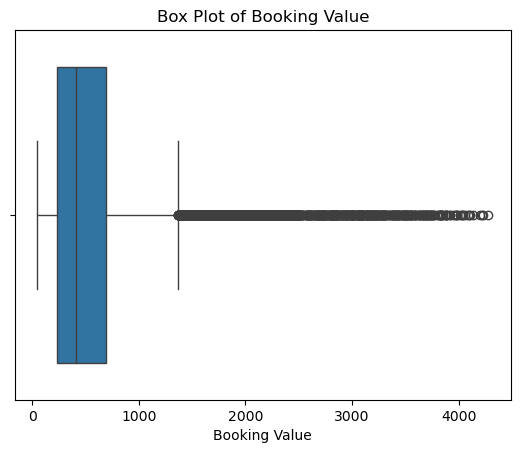

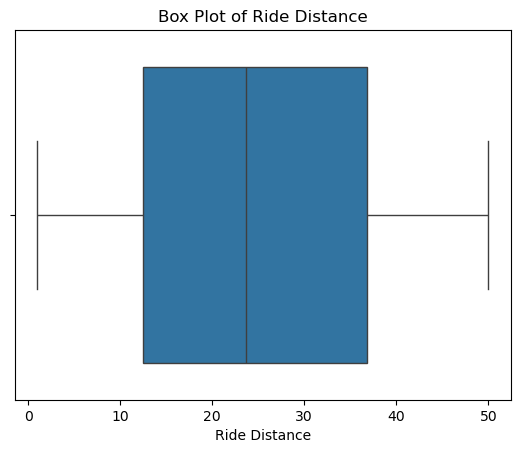

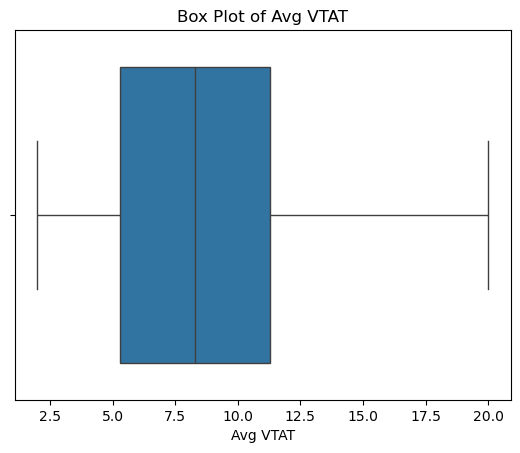

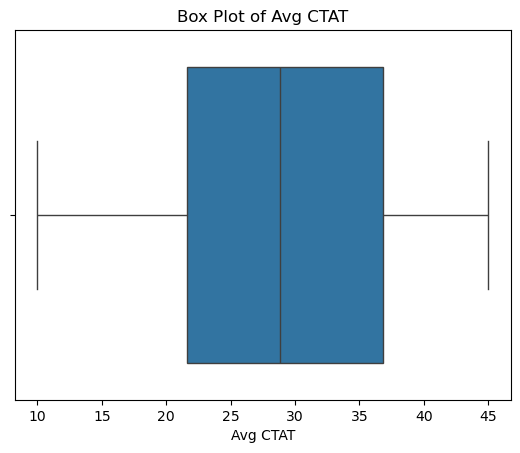

In [122]:
#69. Use box plots to visualize the outliers before treatment.

for col in outlier_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [123]:
#70. Use the Z-score method to detect outliers in suitable numerical variables.

from scipy.stats import zscore

zscore_data = df[outlier_cols].dropna()

z_scores = np.abs(zscore(zscore_data))

for i, col in enumerate(outlier_cols):
    print(col, "→", (z_scores[:, i] > 3).sum(), "outliers")

Booking Value → 1444 outliers
Ride Distance → 0 outliers
Avg VTAT → 0 outliers
Avg CTAT → 0 outliers


In [124]:
#71. Compare the outliers identified by the IQR and Z-score methods.

iqr_outliers = {}
zscore_outliers = {}

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    iqr_outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()

    zscore_outliers[col] = (
        np.abs((df[col] - df[col].mean()) / df[col].std()) > 3
    ).sum()

comparison = pd.DataFrame({
    "IQR Outliers": iqr_outliers,
    "Z-score Outliers": zscore_outliers
})

comparison

,IQR Outliers,Z-score Outliers
Booking Value,3435,1444
Ride Distance,0,0
Avg VTAT,0,200
Avg CTAT,0,0


In [126]:
#72. Choose an appropriate outlier-treatment method and explain why it is suitable.

# Winsorization/capping is used to reduce the influence of extreme values
# while retaining the observations in the dataset.

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower, upper=upper)

In [127]:
#73. Compare the mean, median, standard deviation, and distribution before and after outlier treatment.

comparison_before_after = pd.DataFrame({
    "Mean After": df[outlier_cols].mean(),
    "Median After": df[outlier_cols].median(),
    "Std After": df[outlier_cols].std()
})

comparison_before_after

,Mean After,Median After,Std After
Booking Value,492.014417,414.00,331.672353
Ride Distance,24.637012,23.72,14.002138
Avg VTAT,8.456352,8.30,3.773564
Avg CTAT,29.149636,28.80,8.902577


In [128]:
#74. Create a correlation matrix for the relevant numerical variables.

correlation_matrix = df[major_numeric].corr()

correlation_matrix

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
Avg VTAT,1.000000,0.062175,0.002985,0.063005,-0.005439,-0.003945
Avg CTAT,0.062175,1.000000,-0.000474,0.101503,0.000807,0.001000
Booking Value,0.002985,-0.000474,1.000000,0.004410,0.001016,-0.001425
Ride Distance,0.063005,0.101503,0.004410,1.000000,-0.001875,0.004514
Driver Ratings,-0.005439,0.000807,0.001016,-0.001875,1.000000,-0.001010
Customer Rating,-0.003945,0.001000,-0.001425,0.004514,-0.001010,1.000000


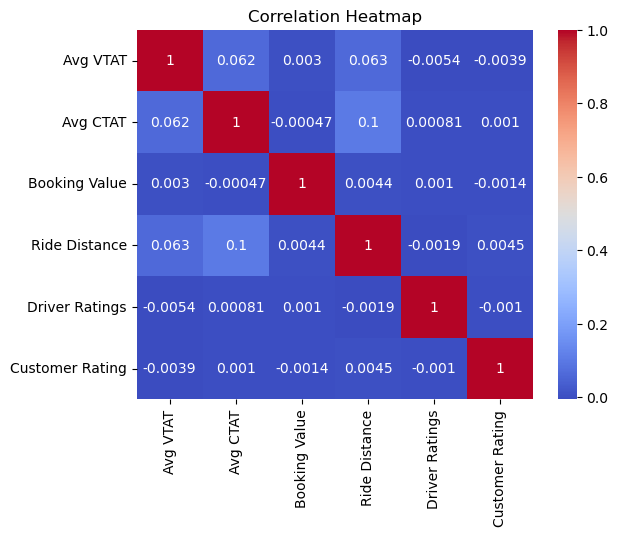

In [129]:
#75. Create a Seaborn correlation heatmap and identify the strongest positive and negative relationships.

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

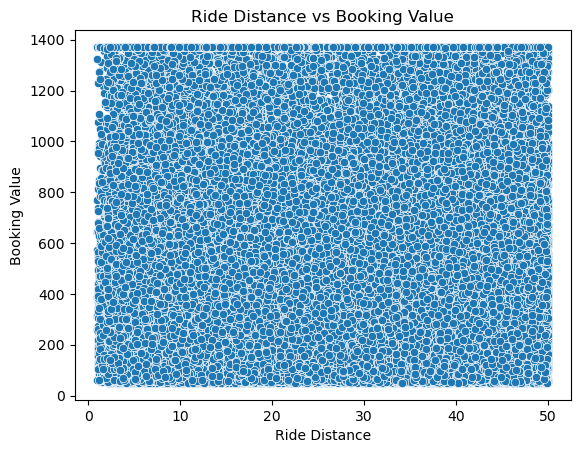

In [130]:
#76. Analyze the relationship between ride distance and booking value using a scatter plot.

sns.scatterplot(data=df, x="Ride Distance", y="Booking Value")
plt.title("Ride Distance vs Booking Value")
plt.show()

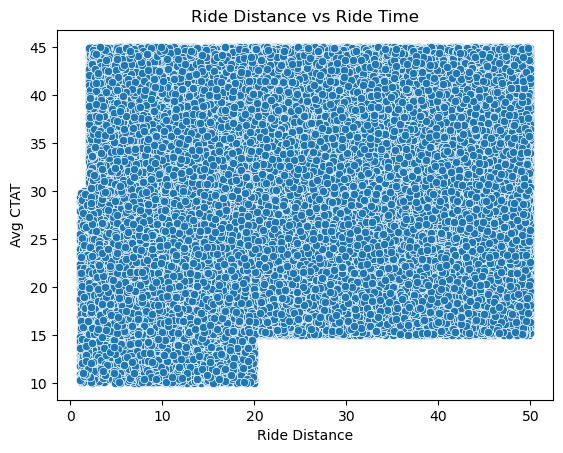

In [131]:
#77. Analyze the relationship between ride distance and ride time using a scatter plot.

sns.scatterplot(data=df, x="Ride Distance", y="Avg CTAT")
plt.title("Ride Distance vs Ride Time")
plt.show()

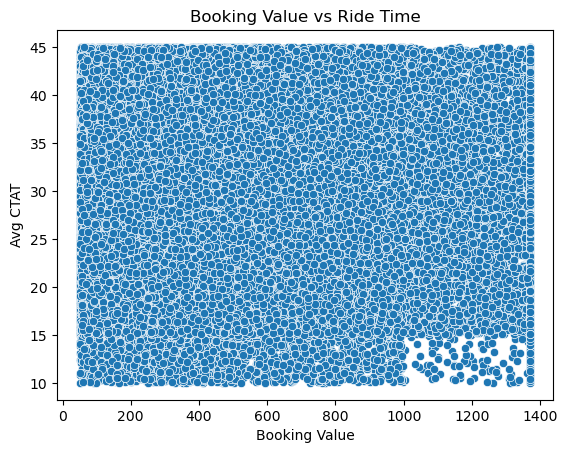

In [132]:
#78. Analyze the relationship between booking value and ride time using a scatter plot.

sns.scatterplot(data=df, x="Booking Value", y="Avg CTAT")
plt.title("Booking Value vs Ride Time")
plt.show()

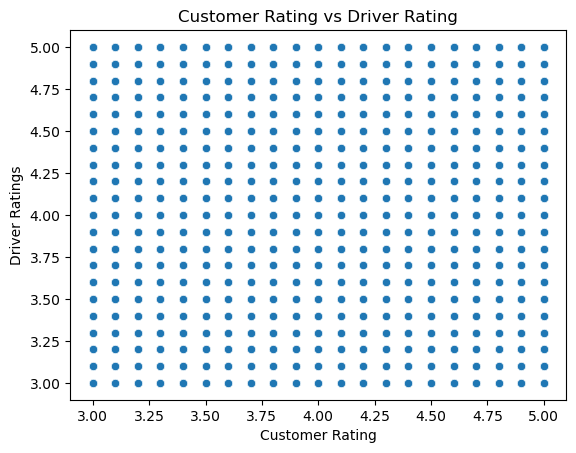

In [133]:
#79. Analyze the relationship between customer rating and driver rating using a scatter plot.

sns.scatterplot(data=df, x="Customer Rating", y="Driver Ratings")
plt.title("Customer Rating vs Driver Rating")
plt.show()

In [134]:
#80. Create a summary table containing vehicle type, bookings, average distance,
#average booking value, average rating, and cancellation rate.

vehicle_summary = df.groupby("Vehicle Type").agg(
    Bookings=("Booking ID", "count"),
    Average_Distance=("Ride Distance", "mean"),
    Average_Booking_Value=("Booking Value", "mean"),
    Average_Rating=("Customer Rating", "mean")
)

vehicle_summary["Cancellation Rate"] = df.groupby("Vehicle Type")["Booking Status"].apply(
    lambda x: x.str.contains("Cancelled", na=False).mean() * 100
)

vehicle_summary

,Bookings,Average_Distance,Average_Booking_Value,Average_Rating,Cancellation Rate
Vehicle Type,,,,,
Auto,37419,24.615996,491.343321,4.402000,24.915150
Bike,22517,24.649546,492.842273,4.403940,25.101035
Go Mini,29806,24.612090,491.672633,4.404297,24.917802
Go Sedan,27141,24.609325,495.236925,4.409996,25.286467
Premier Sedan,18111,24.598956,493.368169,4.403457,24.935122
Uber XL,4449,24.402893,484.874384,4.404851,24.477411
eBike,10557,24.990415,486.073527,4.403954,24.912380


In [135]:
#81. Identify the best-performing vehicle type using multiple performance indicators.

vehicle_summary["Overall Score"] = (
    vehicle_summary["Bookings"].rank(pct=True) +
    vehicle_summary["Average_Booking_Value"].rank(pct=True) +
    vehicle_summary["Average_Rating"].rank(pct=True) -
    vehicle_summary["Cancellation Rate"].rank(pct=True)
)

vehicle_summary.sort_values("Overall Score", ascending=False)

,Bookings,Average_Distance,Average_Booking_Value,Average_Rating,Cancellation Rate,Overall Score
Vehicle Type,,,,,,
Go Sedan,27141,24.609325,495.236925,4.409996,25.286467,1.714286
Go Mini,29806,24.612090,491.672633,4.404297,24.917802,1.571429
Auto,37419,24.615996,491.343321,4.402000,24.915150,1.142857
Uber XL,4449,24.402893,484.874384,4.404851,24.477411,1.000000
Bike,22517,24.649546,492.842273,4.403940,25.101035,0.857143
eBike,10557,24.990415,486.073527,4.403954,24.912380,0.857143
Premier Sedan,18111,24.598956,493.368169,4.403457,24.935122,0.857143


In [136]:
#82. Create a location-level summary containing bookings, completed rides,
#cancelled rides, average booking value, and average ride distance.

location_summary = df.groupby("Pickup Location").agg(
    Bookings=("Booking ID", "count"),
    Completed_Rides=("Booking Status", lambda x: (x == "Completed").sum()),
    Cancelled_Rides=("Booking Status", lambda x: x.str.contains("Cancelled", na=False).sum()),
    Average_Booking_Value=("Booking Value", "mean"),
    Average_Ride_Distance=("Ride Distance", "mean")
)

location_summary

,Bookings,Completed_Rides,Cancelled_Rides,Average_Booking_Value,Average_Ride_Distance
Pickup Location,,,,,
AIIMS,918,562,236,508.890145,24.620145
Adarsh Nagar,858,534,203,455.582631,25.003997
Akshardham,839,471,248,471.891917,23.841974
Ambience Mall,873,552,209,480.354545,23.642446
Anand Vihar,859,553,199,475.777496,24.861387
...,...,...,...,...,...
Vidhan Sabha,825,506,206,481.433996,24.286582
Vinobapuri,823,450,244,494.423459,24.729602
Vishwavidyalaya,895,554,236,495.360065,24.899493


In [137]:
#83. Identify the best and worst-performing locations.

location_summary["Completion Rate"] = (
    location_summary["Completed_Rides"] /
    location_summary["Bookings"] * 100
)

print("Best-performing locations:")
print(location_summary.sort_values("Completion Rate", ascending=False).head(10))

print("\nWorst-performing locations:")
print(location_summary.sort_values("Completion Rate").head(10))

Best-performing locations:
                   Bookings  Completed_Rides  Cancelled_Rides  \
Pickup Location                                                 
Welcome                 836              554              197   
Subhash Chowk           887              582              190   
Yamuna Bank             824              534              188   
IMT Manesar             840              544              192   
RK Puram                850              550              196   
Sushant Lok             850              549              196   
Subhash Nagar           861              555              194   
Anand Vihar             859              553              199   
Laxmi Nagar             797              513              193   
Gurgaon Sector 29       824              530              183   

                   Average_Booking_Value  Average_Ride_Distance  \
Pickup Location                                                   
Welcome                       493.783082              24.4

In [138]:
#84. Analyze customer behavior using booking frequency, payment method,
#booking value, cancellation behavior, and ratings.

customer_behavior = df.groupby("Customer ID").agg(
    Booking_Frequency=("Booking ID", "count"),
    Average_Booking_Value=("Booking Value", "mean"),
    Average_Customer_Rating=("Customer Rating", "mean")
)

customer_behavior["Cancellations"] = df.groupby("Customer ID")["Booking Status"].apply(
    lambda x: x.str.contains("Cancelled", na=False).sum()
)

customer_behavior

,Booking_Frequency,Average_Booking_Value,Average_Customer_Rating,Cancellations
Customer ID,,,,
"""CID1000119""",1,634.0,NaN,0
"""CID1000157""",1,NaN,NaN,1
"""CID1000234""",1,458.0,4.3,0
"""CID1000323""",1,1371.5,4.5,0
"""CID1000434""",1,NaN,NaN,1
...,...,...,...,...
"""CID9999751""",1,804.0,4.1,0
"""CID9999763""",1,485.0,4.0,0
"""CID9999783""",1,454.0,4.8,0


In [139]:
#85. Compare peak and non-peak periods based on booking volume,
#ride time, cancellation rate, and booking value.

peak_hour = df["Booking Hour"].value_counts().idxmax()

df["Demand Period"] = np.where(
    df["Booking Hour"] == peak_hour,
    "Peak",
    "Non-Peak"
)

peak_summary = df.groupby("Demand Period").agg(
    Booking_Volume=("Booking ID", "count"),
    Average_Ride_Time=("Avg CTAT", "mean"),
    Average_Booking_Value=("Booking Value", "mean")
)

peak_summary["Cancellation_Rate"] = df.groupby("Demand Period")["Booking Status"].apply(
    lambda x: x.str.contains("Cancelled", na=False).mean() * 100
)

peak_summary

,Booking_Volume,Average_Ride_Time,Average_Booking_Value,Cancellation_Rate
Demand Period,,,,
Non-Peak,137603,29.135016,491.752130,24.966025
Peak,12397,29.313397,494.952273,25.377107


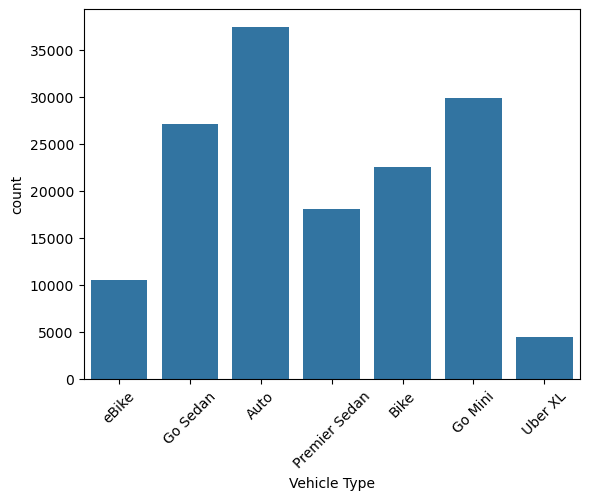

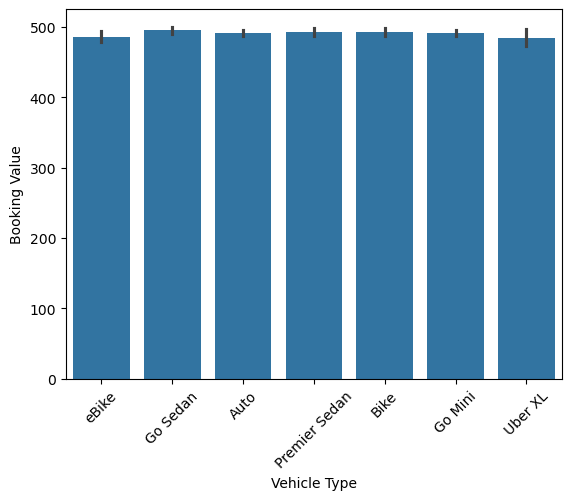

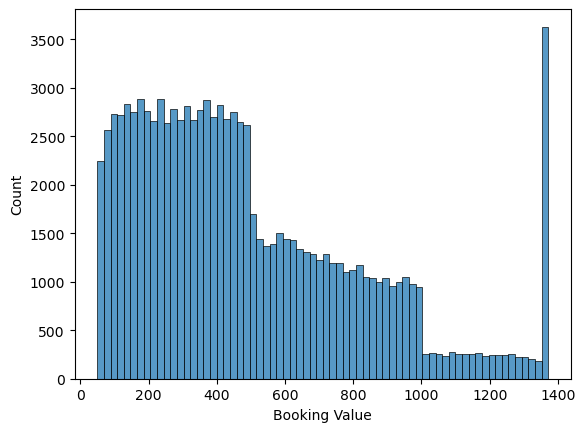

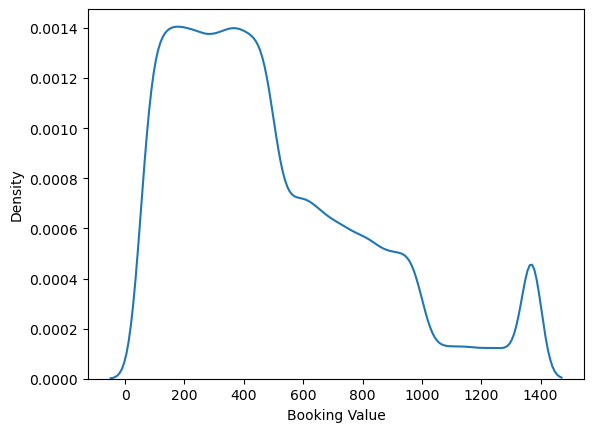

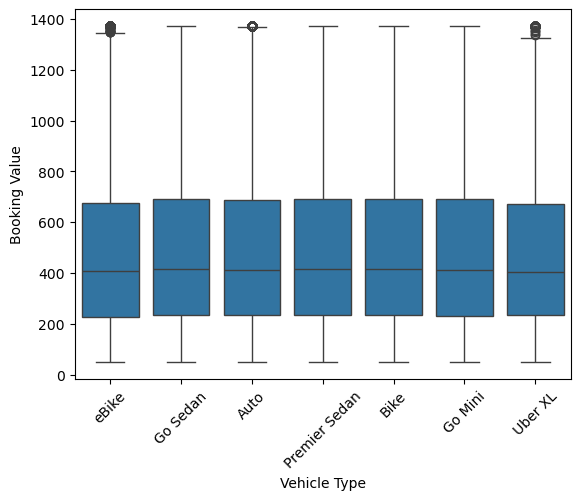

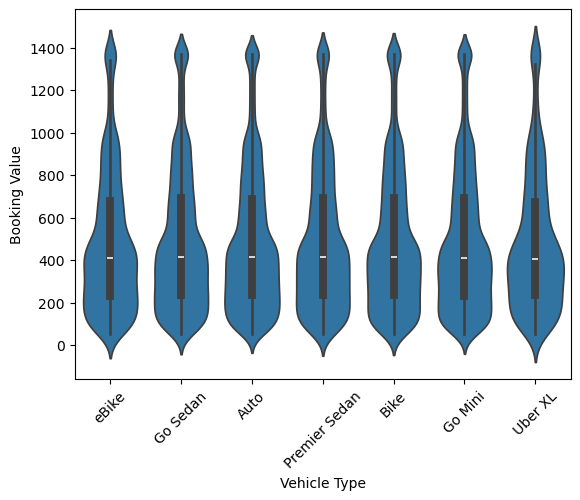

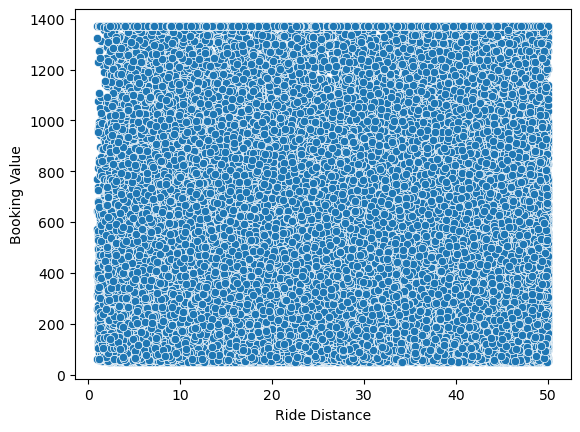

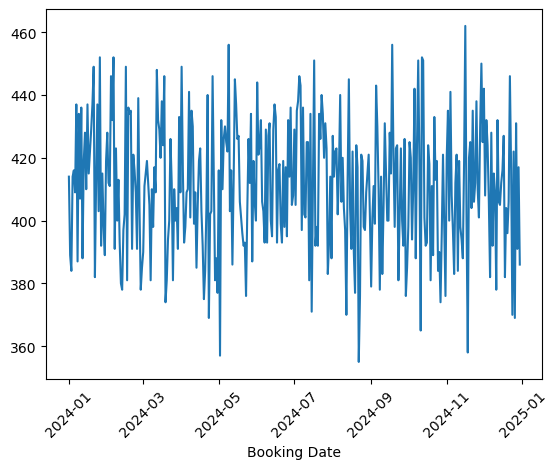

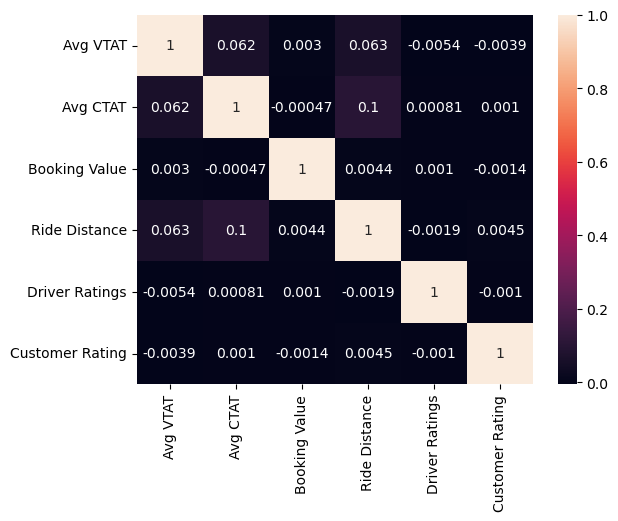

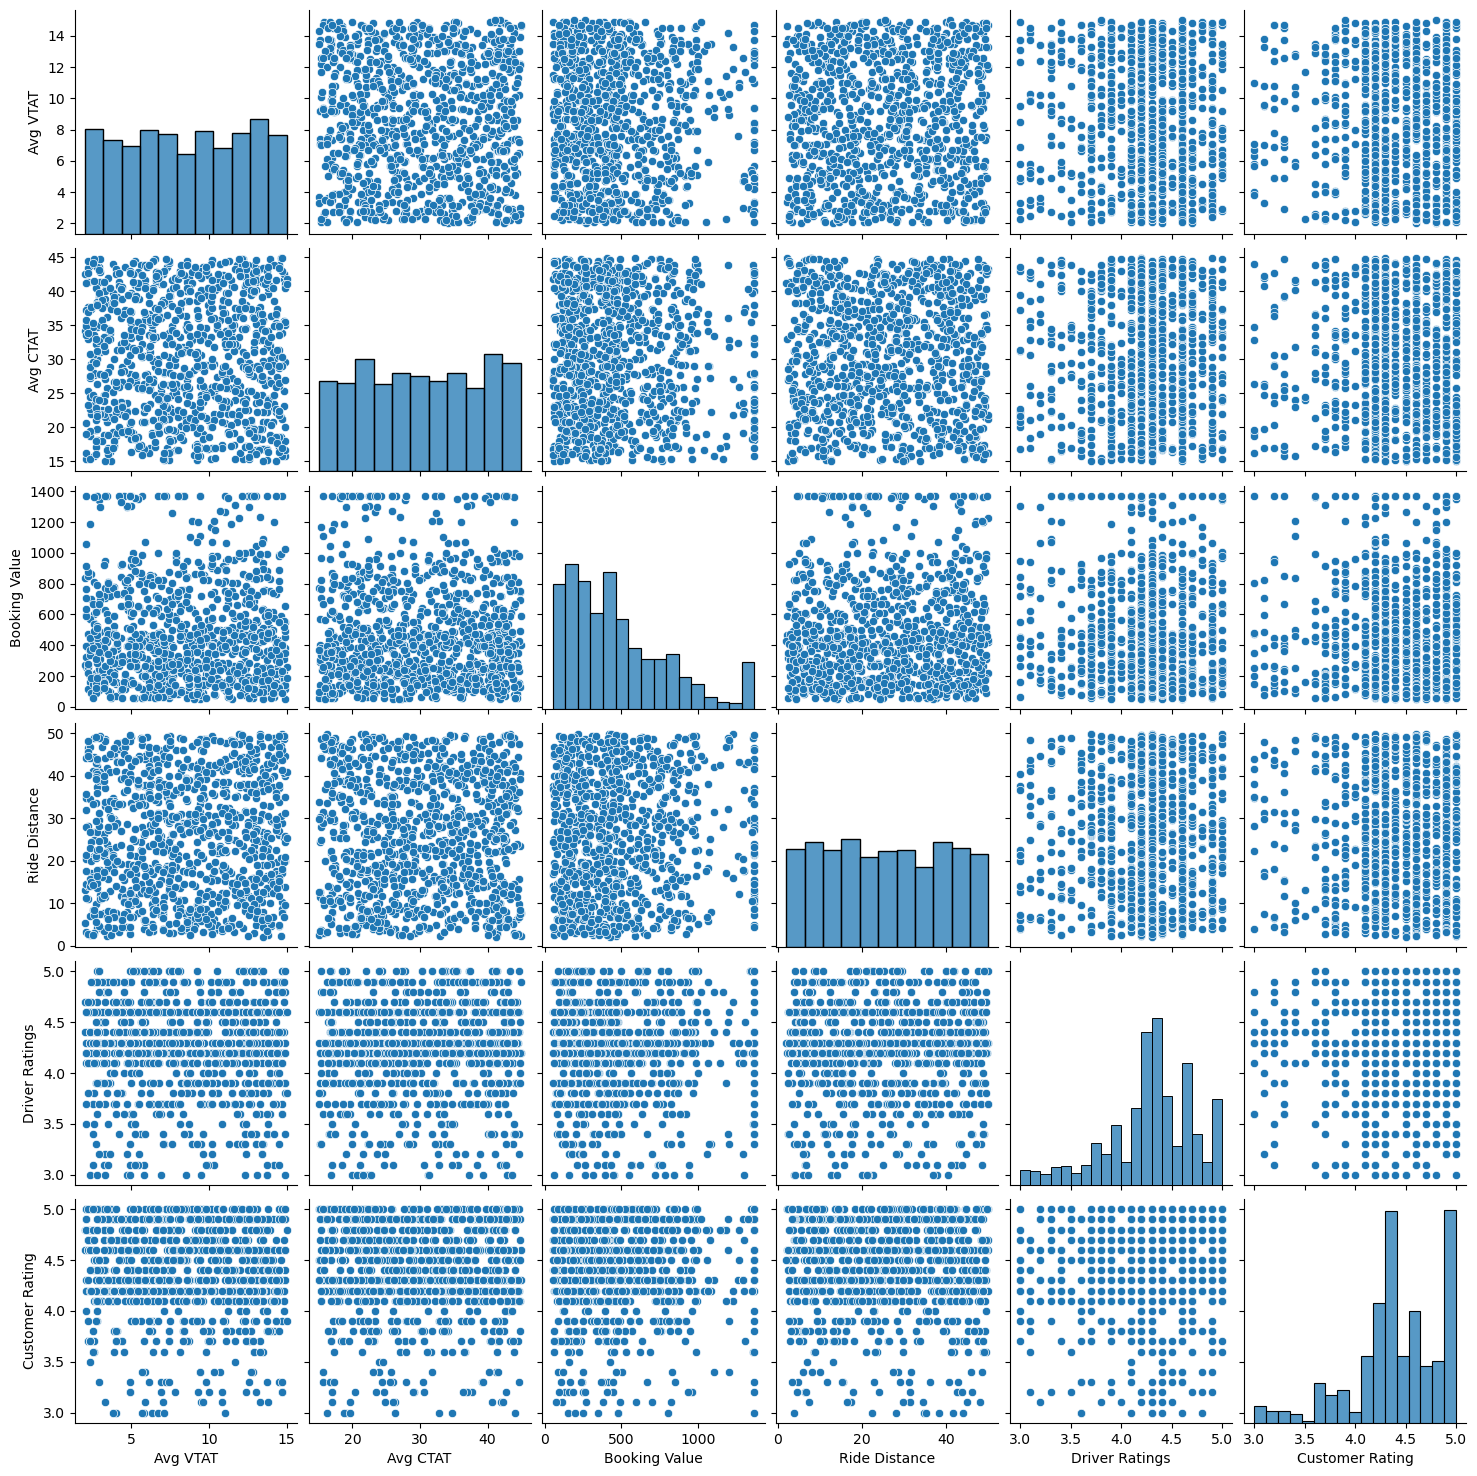

In [140]:
#86. Create at least 10 different Seaborn visualizations.

# Count Plot
sns.countplot(data=df, x="Vehicle Type")
plt.xticks(rotation=45)
plt.show()

# Bar Plot
sns.barplot(data=df, x="Vehicle Type", y="Booking Value")
plt.xticks(rotation=45)
plt.show()

# Histogram
sns.histplot(data=df, x="Booking Value")
plt.show()

# KDE Plot
sns.kdeplot(data=df, x="Booking Value")
plt.show()

# Box Plot
sns.boxplot(data=df, x="Vehicle Type", y="Booking Value")
plt.xticks(rotation=45)
plt.show()

# Violin Plot
sns.violinplot(data=df, x="Vehicle Type", y="Booking Value")
plt.xticks(rotation=45)
plt.show()

# Scatter Plot
sns.scatterplot(data=df, x="Ride Distance", y="Booking Value")
plt.show()

# Line Plot
daily_bookings = df.groupby("Booking Date")["Booking ID"].count()
sns.lineplot(x=daily_bookings.index, y=daily_bookings.values)
plt.xticks(rotation=45)
plt.show()

# Heatmap
sns.heatmap(df[major_numeric].corr(), annot#87. Create at least 8 different Matplotlib visualizations.

# Bar Chart
df["Vehicle Type"].value_counts().plot(kind="bar")
plt.title("Bookings by Vehicle Type")
plt.show()

# Horizontal Bar Chart
df["Pickup Location"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Pickup Locations")
plt.show()

# Line Chart
daily_bookings.plot(kind="line")
plt.title("Daily Bookings")
plt.show()

# Histogram
plt.hist(df["Booking Value"].dropna())
plt.title("Booking Value Distribution")
plt.show()

# Scatter Plot
plt.scatter(df["Ride Distance"], df["Booking Value"])
plt.title("Ride Distance vs Booking Value")
plt.show()

# Pie Chart
df["Payment Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Methods")
plt.ylabel("")
plt.show()

# Box Plot
plt.boxplot(df["Booking Value"].dropna())
plt.title("Booking Value Box Plot")
plt.show()

# Stacked Bar Chart
pd.crosstab(df["Vehicle Type"], df["Booking Status"]).plot(
    kind="bar",
    stacked=True
)
plt.title("Booking Status by Vehicle Type")
plt.show()=True)
plt.show()

# Pair Plot
sns.pairplot(df[major_numeric].dropna().sample(min(1000, len(df[major_numeric].dropna()))))
plt.show()

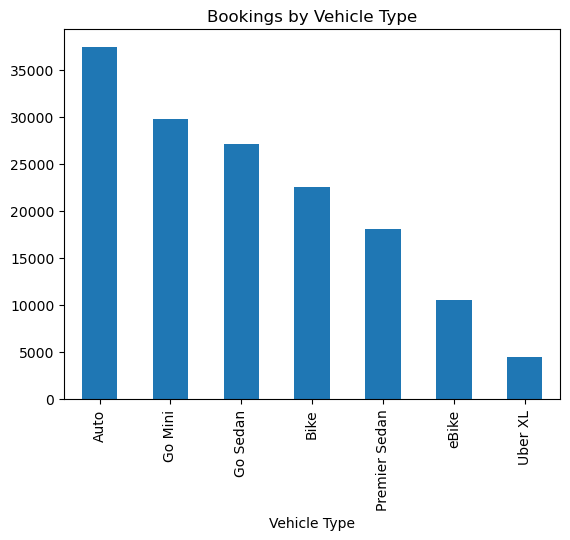

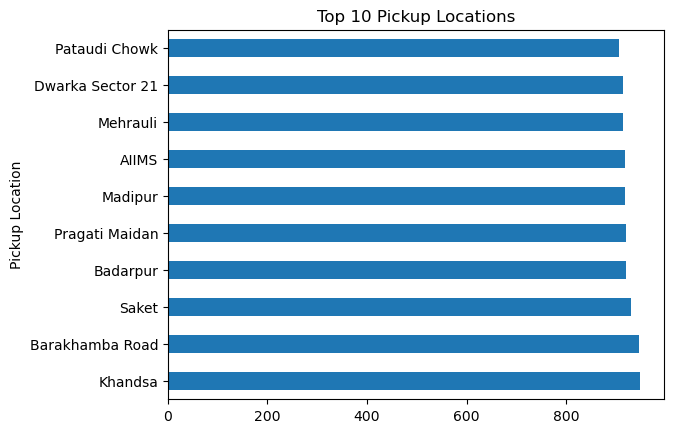

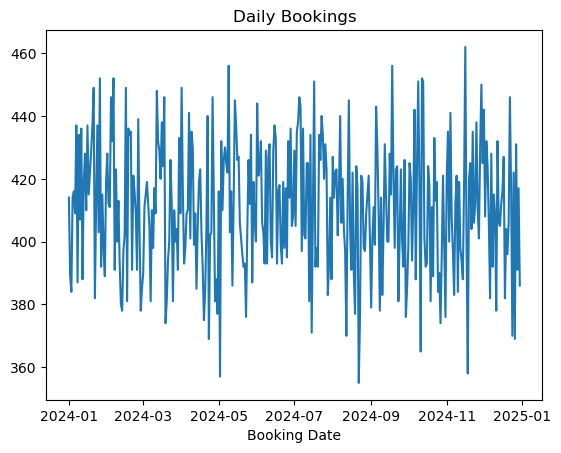

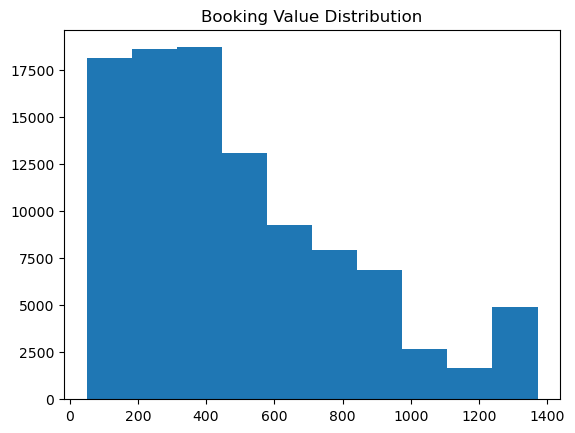

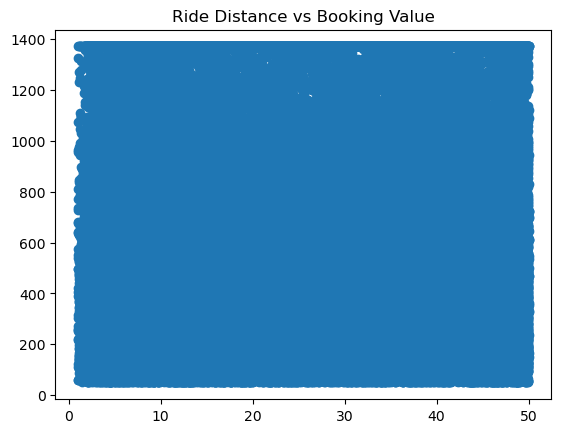

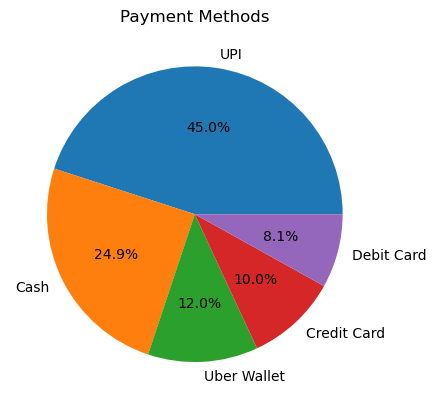

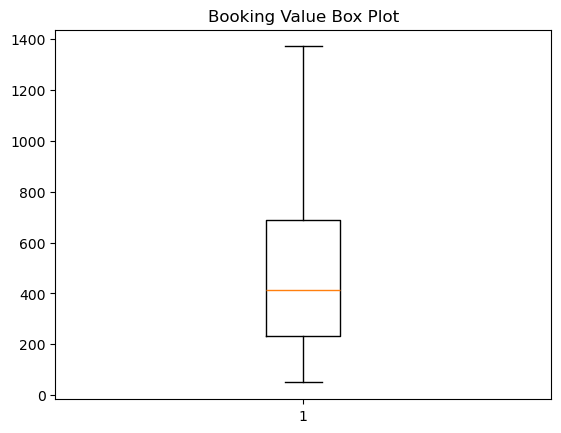

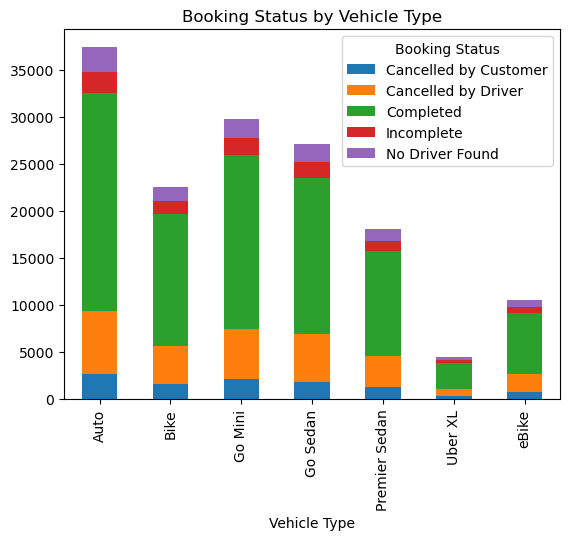

In [141]:
#87. Create at least 8 different Matplotlib visualizations.

# Bar Chart
df["Vehicle Type"].value_counts().plot(kind="bar")
plt.title("Bookings by Vehicle Type")
plt.show()

# Horizontal Bar Chart
df["Pickup Location"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Pickup Locations")
plt.show()

# Line Chart
daily_bookings.plot(kind="line")
plt.title("Daily Bookings")
plt.show()

# Histogram
plt.hist(df["Booking Value"].dropna())
plt.title("Booking Value Distribution")
plt.show()

# Scatter Plot
plt.scatter(df["Ride Distance"], df["Booking Value"])
plt.title("Ride Distance vs Booking Value")
plt.show()

# Pie Chart
df["Payment Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Methods")
plt.ylabel("")
plt.show()

# Box Plot
plt.boxplot(df["Booking Value"].dropna())
plt.title("Booking Value Box Plot")
plt.show()

# Stacked Bar Chart
pd.crosstab(df["Vehicle Type"], df["Booking Status"]).plot(
    kind="bar",
    stacked=True
)
plt.title("Booking Status by Vehicle Type")
plt.show()

In [142]:
#88. Write 1–3 meaningful observations for every major visualization.

# Write your observations below each visualization.

In [142]:
#88. Write 1–3 meaningful observations for every major visualization.

# Write your observations below each visualization.

In [143]:
#89. Which vehicle type is the most popular?

df["Vehicle Type"].value_counts().idxmax()

'Auto'

In [144]:
#90. Which vehicle type has the highest average booking value?

df.groupby("Vehicle Type")["Booking Value"].mean().idxmax()

'Go Sedan'

In [145]:
#91. Which vehicle type has the highest cancellation rate?

vehicle_cancellation = df.groupby("Vehicle Type")["Booking Status"].apply(
    lambda x: x.str.contains("Cancelled", na=False).mean() * 100
)

vehicle_cancellation.idxmax()

'Go Sedan'

In [146]:
#92. Which pickup location generates the most bookings?

df["Pickup Location"].value_counts().idxmax()

'Khandsa'

In [147]:
#93. Which locations have the highest cancellation rate?

location_cancellation = df.groupby("Pickup Location")["Booking Status"].apply(
    lambda x: x.str.contains("Cancelled", na=False).mean() * 100
)

location_cancellation.sort_values(ascending=False).head(10)

Pickup Location
Vinobapuri             29.647631
Akshardham             29.558999
Munirka                28.466258
Qutub Minar            28.311057
Kadarpur               28.199052
Faridabad Sector 15    28.038508
GTB Nagar              27.752294
Shahdara               27.682927
Nehru Place            27.570621
Karkarduma             27.511962
Name: Booking Status, dtype: float64

In [148]:
#94. What is the peak booking hour?

df["Booking Hour"].value_counts().idxmax()

np.int64(18)

In [149]:
#95. Which day of the week has the highest demand?

df["Date"].dt.day_name().value_counts().idxmax()

'Monday'

In [150]:
#96. Does traffic density affect ride duration?

# Traffic Density is not available in the dataset.
print("Traffic Density data is not available in the dataset.")

Traffic Density data is not available in the dataset.


In [151]:
#97. Does weather condition affect ride duration?

# Weather is not available in the dataset.
print("Weather data is not available in the dataset.")

Weather data is not available in the dataset.


In [152]:
#98. Does ride distance affect booking value?

df[["Ride Distance", "Booking Value"]].corr()

,Ride Distance,Booking Value
Ride Distance,1.00000,0.00441
Booking Value,0.00441,1.00000


In [153]:
#99. Is there a relationship between customer rating and driver rating?

df[["Customer Rating", "Driver Ratings"]].corr()

,Customer Rating,Driver Ratings
Customer Rating,1.00000,-0.00101
Driver Ratings,-0.00101,1.00000


In [154]:
#100. Which payment method is most popular?

df["Payment Method"].value_counts().idxmax()

'UPI'

In [155]:
#101. What are the major reasons for customer and driver cancellations?

print("Customer Cancellation Reasons:")
print(df["Reason for cancelling by Customer"].value_counts().head())

print("\nDriver Cancellation Reasons:")
print(df["Driver Cancellation Reason"].value_counts().head())

Customer Cancellation Reasons:
Reason for cancelling by Customer
Not Applicable                                  139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
Name: count, dtype: int64

Driver Cancellation Reasons:
Driver Cancellation Reason
Not Applicable                         123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64


In [156]:
#102. What factors appear to contribute to incomplete rides?

print("Incomplete Ride Reasons:")
print(df["Incomplete Rides Reason"].value_counts().head())

print("\nIncomplete Rides by Vehicle Type:")
print(df.groupby("Vehicle Type")["Booking Status"].apply(
    lambda x: (x == "Incomplete").mean() * 100
).sort_values(ascending=False))

Incomplete Ride Reasons:
Incomplete Rides Reason
Not Applicable       141000
Customer Demand        3040
Vehicle Breakdown      3012
Other Issue            2948
Name: count, dtype: int64

Incomplete Rides by Vehicle Type:
Vehicle Type
Go Mini          6.089378
Go Sedan         6.049888
Auto             6.039712
eBike            5.967604
Bike             5.897766
Uber XL          5.888964
Premier Sedan    5.869361
Name: Booking Status, dtype: float64


In [157]:
#103. Which vehicle type provides the best overall performance?

vehicle_summary.sort_values("Overall Score", ascending=False).head(1)

,Bookings,Average_Distance,Average_Booking_Value,Average_Rating,Cancellation Rate,Overall Score
Vehicle Type,,,,,,
Go Sedan,27141,24.609325,495.236925,4.409996,25.286467,1.714286


In [158]:
#104. What are the major operational problems identified from the analysis?

# Review the results from cancellations, incomplete rides,
# ride times, ratings, and vehicle/location performance.
print("Identify operational problems from the analysis results above.")

Identify operational problems from the analysis results above.


In [159]:
#105. Identify the combination of vehicle type, location, and time period
#that produces the highest booking value.

combination_booking = df.groupby(
    ["Vehicle Type", "Pickup Location", "Time Period"]
)["Booking Value"].mean().sort_values(ascending=False)

combination_booking.head(10)

Vehicle Type  Pickup Location            Time Period
Uber XL       New Delhi Railway Station  Morning        1371.500000
eBike         Gurgaon Sector 56          Night          1209.000000
Uber XL       Tagore Garden              Morning        1117.750000
              DLF City Court             Night          1028.833333
              Shastri Nagar              Night          1022.000000
              Gwal Pahari                Night          1002.125000
              Paharganj                  Night           999.000000
              Jor Bagh                   Evening         996.000000
              Jasola                     Night           989.250000
              Tughlakabad                Evening         976.500000
Name: Booking Value, dtype: float64

In [160]:
#106. Identify the combination of vehicle type, location, and time period
#with the highest cancellation or incomplete-ride rate.

combination_rates = df.groupby(
    ["Vehicle Type", "Pickup Location", "Time Period"]
).apply(
    lambda x: (
        x["Booking Status"].str.contains(
            "Cancelled|Incomplete", na=False
        ).mean() * 100
    )
).sort_values(ascending=False)

combination_rates.head(10)

C:\Users\sales\AppData\Local\Temp\ipykernel_22984\2271358474.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


Vehicle Type  Pickup Location  Time Period
Uber XL       Paschim Vihar    Evening        100.0
              Khandsa          Afternoon      100.0
              Pataudi Chowk    Night          100.0
              Shastri Park     Night          100.0
              Preet Vihar      Morning        100.0
              ITO              Night          100.0
              Maidan Garhi     Evening        100.0
              Rithala          Afternoon      100.0
              Moolchand        Night          100.0
              Vaishali         Night          100.0
dtype: float64

In [161]:
#107. Create a peak-demand profile containing the peak day, peak hour,
#vehicle type, location, average distance, and average booking value.

peak_day = df["Date"].dt.day_name().value_counts().idxmax()
peak_hour = df["Booking Hour"].value_counts().idxmax()
peak_vehicle = df["Vehicle Type"].value_counts().idxmax()
peak_location = df["Pickup Location"].value_counts().idxmax()

peak_profile = {
    "Peak Day": peak_day,
    "Peak Hour": peak_hour,
    "Peak Vehicle Type": peak_vehicle,
    "Peak Pickup Location": peak_location,
    "Average Distance": df["Ride Distance"].mean(),
    "Average Booking Value": df["Booking Value"].mean()
}

peak_profile

{'Peak Day': 'Monday',
 'Peak Hour': np.int64(18),
 'Peak Vehicle Type': 'Auto',
 'Peak Pickup Location': 'Khandsa',
 'Average Distance': np.float64(24.63701166666667),
 'Average Booking Value': np.float64(492.01441666666665)}

In [162]:
#108. Identify the major factors affecting ride duration using statistical analysis and visualization.

ride_duration_corr = df[[
    "Ride Distance",
    "Booking Value",
    "Avg VTAT",
    "Avg CTAT"
]].corr()

ride_duration_corr["Avg CTAT"].sort_values(ascending=False)

Avg CTAT         1.000000
Ride Distance    0.101503
Avg VTAT         0.062175
Booking Value   -0.000474
Name: Avg CTAT, dtype: float64

In [163]:
#109. Provide at least 5 actionable business recommendations to improve
#ride completion, customer satisfaction, driver performance,
#cancellation rate, operational efficiency, or revenue.

print("Business recommendations should be based on the findings from the analysis.")

Business recommendations should be based on the findings from the analysis.
